In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn 
import matplotlib.cm as cm  # Correct import for colormaps
# The 3D import is only needed for 3D plots
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sb_og_dirac import *

In [4]:
def create_eight_gaussians(n_points_per_cluster=500, std=0.05):
    """
    Generates the eight-Gaussian dataset.

    Args:
        n_points_per_cluster: The number of points to generate for each Gaussian.
        std: The standard deviation of each Gaussian.

    Returns:
        A NumPy array of shape (n_points_per_cluster * 8, 2) containing the data.
    """
    # Define the centers of the eight Gaussian clusters
    centers = [
        (np.cos(np.pi / 4 * i), np.sin(np.pi / 4 * i))
        for i in range(8)
    ]
    centers = np.array(centers)

    # Scale and add noise to create the points
    data = []
    for center in centers:
        # Generate random points from a 2D Gaussian
        points = np.random.normal(loc=center, scale=std, size=(n_points_per_cluster, 2))
        data.append(points)

    return np.concatenate(data, axis=0)

In [5]:
dataset = create_eight_gaussians(std=0.1)

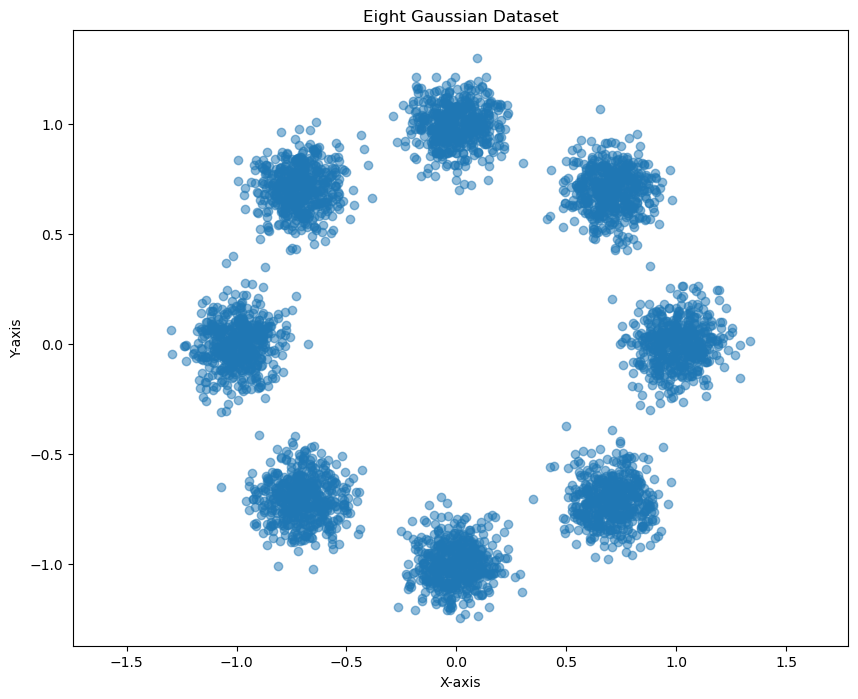

In [6]:
plt.figure(figsize=(10, 8))
plt.scatter(dataset[:, 0], dataset[:, 1], alpha=0.5)
plt.title('Eight Gaussian Dataset')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()

In [7]:
Xdata=torch.tensor(dataset,dtype=torch.float32)

In [8]:
N=200;
sde=SDE_eps(N,Xdata,1e-7)

x0=torch.zeros(2)
M=4000;
Xlist=list()
for i in range(M):
    xx1=sde.forward(x0)
    Xlist.append(xx1)
Xg=torch.stack(Xlist)

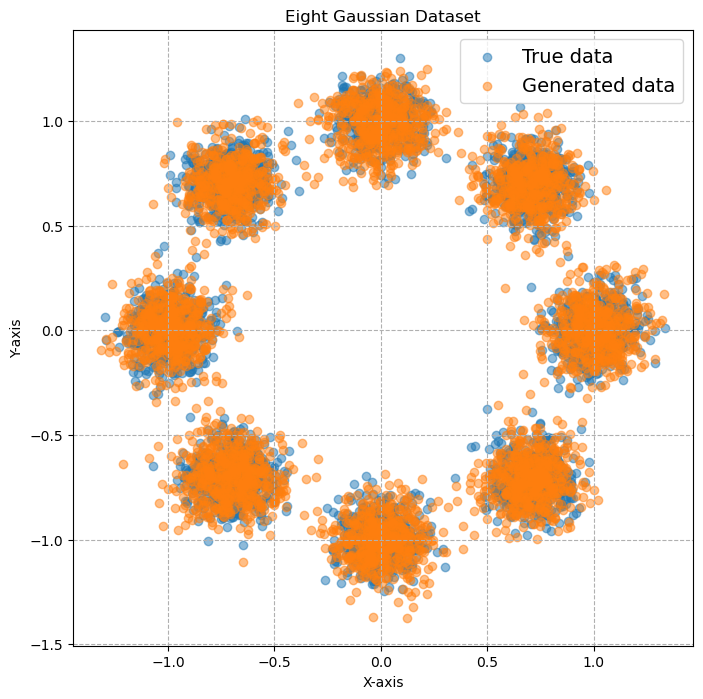

In [33]:
plt.figure(figsize=(8, 8))
plt.scatter(dataset[:, 0], dataset[:, 1], alpha=0.5)
plt.scatter(Xg[:, 0], Xg[:, 1], alpha=0.5)
plt.title('Eight Gaussian Dataset')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(linestyle='--')
plt.legend(['True data','Generated data'], fontsize=14)
#plt.savefig('eight_Gaussian.png')
#plt.axis('equal')
#plt.show()